<h3>Happy Customers</h3>

<h4>Notebook 3</h4>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bespoke functions
from model_evaluation import *
from data_prep import * 
from save_model import *

<h4>Support Vector Classifier Modelling</h4>

There are two options: linear and non-linear modelling.

- 0.3 test size:

In [ ]:
X, Y = generate_XY()
X_train_scaled, X_test_scaled, Y_train, Y_test = split_scale_data(X=X,Y=Y,stratify=Y["Y"],test_size=0.3)

In [8]:
# Linear:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score

svm_linear = SVC(
    kernel='linear',
    C=1.0
)

svm_linear.fit(X_train_scaled, Y_train)
Y_pred = svm_linear.predict(X_test_scaled)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("F1-Score:", f1_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Accuracy: 0.5
F1-Score: 0.5957446808510638
              precision    recall  f1-score   support

           0       0.42      0.29      0.34        17
           1       0.54      0.67      0.60        21

    accuracy                           0.50        38
   macro avg       0.48      0.48      0.47        38
weighted avg       0.48      0.50      0.48        38



In [9]:
# Non-linear (RBF kernel):

svm_rbf = SVC(
    kernel='rbf',
    C=1,
    gamma='auto',
    probability=True
)

svm_rbf.fit(X_train_scaled, Y_train)
Y_pred = svm_rbf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("F1-Score:", f1_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Accuracy: 0.5263157894736842
F1-Score: 0.625
              precision    recall  f1-score   support

           0       0.45      0.29      0.36        17
           1       0.56      0.71      0.62        21

    accuracy                           0.53        38
   macro avg       0.51      0.50      0.49        38
weighted avg       0.51      0.53      0.51        38



- Just by going from liner to non-linear we see and increase in f1-score from 0.60 to 0.62.
- Let's do some hyperparameter tuning on the non-linear model.

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 0.5, 1.0, 10, 100],
    'gamma': ['scale', 0.01, 0.1],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5, #StratifiedKFold in the Grid
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, Y_train)

print(grid.best_params_)
best_svm = grid.best_estimator_

Y_best_pred = best_svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(Y_test, Y_best_pred))
print("F1-Score:", f1_score(Y_test, Y_best_pred))
print(classification_report(Y_test, Y_best_pred))

{'C': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 0.5526315789473685
F1-Score: 0.711864406779661
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.55      1.00      0.71        21

    accuracy                           0.55        38
   macro avg       0.28      0.50      0.36        38
weighted avg       0.31      0.55      0.39        38



/Users/cameroncochrane/Data Projects/Happy-Customers/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cameroncochrane/Data Projects/Happy-Customers/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cameroncochrane/Data Projects/Happy-Customers/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

- F1-score is high but it's only guessing positive (1) values and no negative (0) values?
- Precision and recall for the negative class is 0.

In [ ]:
# Save model to pickle file

svc_folder = "svc_models"

save_model(model=svm_linear,filename="svm_linear",folder=svc_folder)
save_model(model=svm_rbf,filename="svm_rbf",folder=svc_folder)
save_model(model=best_svm,filename="svm_gridcv",folder=svc_folder)

Let's plot a gridplot of Y vs X (for each of X1-X6) to see what the boundary between Y being 0 and 1 for each X1-X6 is:

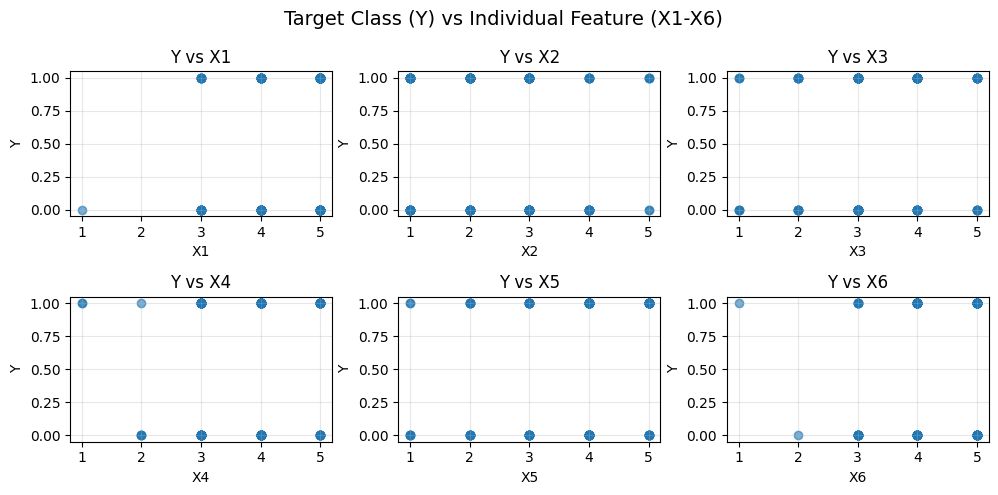

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
axes = axes.ravel()

for idx, col in enumerate(X.columns):
    axes[idx].scatter(X[col], Y['Y'], alpha=0.6)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Y')
    axes[idx].set_title(f'Y vs {col}')
    axes[idx].grid(True, alpha=0.3)

fig.suptitle('Target Class (Y) vs Individual Feature (X1-X6)', fontsize=14)
plt.tight_layout()
plt.show() 

- It's hard to draw a distinction of the value of X and the resultant Y result (when plotted like this).
- As histograms:


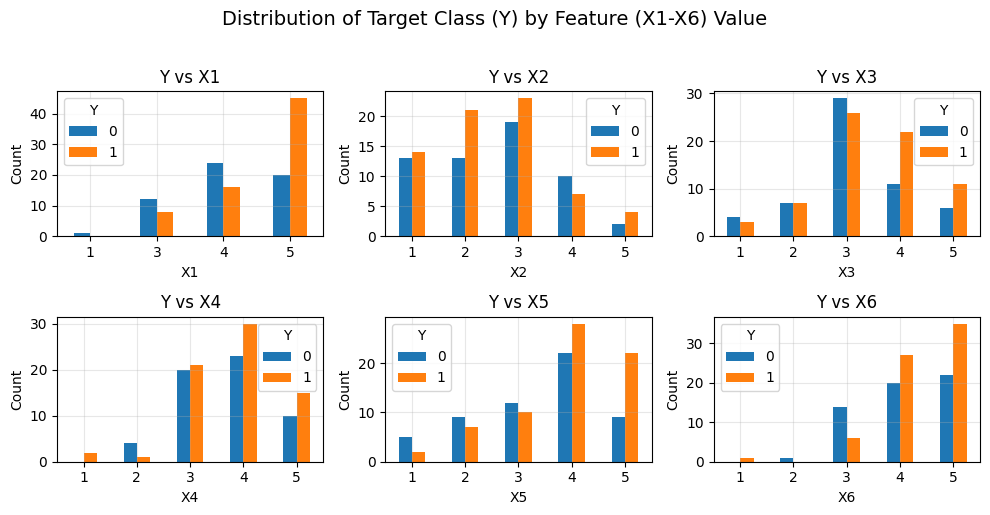

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
axes = axes.ravel()

for idx, col in enumerate(X.columns):
    df_plot = pd.DataFrame({col: X[col], 'Y': Y['Y']})
    df_plot.groupby([col, 'Y']).size().unstack(fill_value=0).plot(kind='bar', ax=axes[idx])
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].set_title(f'Y vs {col}')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=0)

fig.suptitle('Distribution of Target Class (Y) by Feature (X1-X6) Value', fontsize=14, y=1.02)
plt.tight_layout()
plt.show() # Make sure to add to EDA.py script

<h4>Decision Trees Modelling</h4>

Base modelling:

In [14]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()

clf.fit(X_train_scaled, Y_train)
Y_pred = clf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("F1-Score:", f1_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Accuracy: 0.5789473684210527
F1-Score: 0.5789473684210527
              precision    recall  f1-score   support

           0       0.52      0.65      0.58        17
           1       0.65      0.52      0.58        21

    accuracy                           0.58        38
   macro avg       0.59      0.59      0.58        38
weighted avg       0.59      0.58      0.58        38



Hyperparameter Tuning:

In [15]:
# Hyperparameter tuning for DecisionTreeClassifier
dt_param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [None, "sqrt", "log2"]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=13),
    param_grid=dt_param_grid,
    cv=5, #StratifiedKFold in the Grid
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train_scaled, Y_train)

print("Best Params:", dt_grid.best_params_)
print("Best CV F1:", dt_grid.best_score_)

best_dt = dt_grid.best_estimator_
Y_dt_pred = best_dt.predict(X_test_scaled)

print("Accuracy:", accuracy_score(Y_test, Y_dt_pred))
print("F1-Score:", f1_score(Y_test, Y_dt_pred))
print(classification_report(Y_test, Y_dt_pred))

Best Params: {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV F1: 0.7342995169082125
Accuracy: 0.5526315789473685
F1-Score: 0.5405405405405406
              precision    recall  f1-score   support

           0       0.50      0.65      0.56        17
           1       0.62      0.48      0.54        21

    accuracy                           0.55        38
   macro avg       0.56      0.56      0.55        38
weighted avg       0.57      0.55      0.55        38



- The CV (training) F1-score is good but the test one isn't great.
- Would decision trees work better if trained on the most important features?
- Let's drop X3 and X5 (based on the feature selection process carried out earlier)

In [16]:
feature_cols = ['X1', 'X2', 'X4', 'X6']
X_fsc, Y = generate_XY(feature_cols=feature_cols)
X_fsc_train_scaled, X_fsc_test_scaled, Y_train, Y_test = split_scale_data(X=X_fsc,Y=Y,stratify=Y["Y"],test_size=0.3)

In [17]:
clf_fsc = DecisionTreeClassifier()

clf_fsc.fit(X_fsc_train_scaled, Y_train)
Y_pred = clf_fsc.predict(X_fsc_test_scaled)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("F1-Score:", f1_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Accuracy: 0.5789473684210527
F1-Score: 0.5555555555555556
              precision    recall  f1-score   support

           0       0.52      0.71      0.60        17
           1       0.67      0.48      0.56        21

    accuracy                           0.58        38
   macro avg       0.59      0.59      0.58        38
weighted avg       0.60      0.58      0.58        38



+Hyperparameter Tuning:

In [18]:
dt_fsc_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=13),
    param_grid=dt_param_grid,
    cv=5, #StratifiedKFold in the Grid
    scoring="f1",
    n_jobs=-1
)

dt_fsc_grid.fit(X_fsc_train_scaled, Y_train)

print("Best Params:", dt_grid.best_params_)
print("Best CV F1:", dt_grid.best_score_)

best_fsc_dt = dt_fsc_grid.best_estimator_
Y_dt_fsc_pred = best_fsc_dt.predict(X_fsc_test_scaled)

print("Accuracy:", accuracy_score(Y_test, Y_dt_fsc_pred))
print("F1-Score:", f1_score(Y_test, Y_dt_fsc_pred))
print(classification_report(Y_test, Y_dt_fsc_pred))

Best Params: {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV F1: 0.7342995169082125
Accuracy: 0.6052631578947368
F1-Score: 0.6808510638297872
              precision    recall  f1-score   support

           0       0.58      0.41      0.48        17
           1       0.62      0.76      0.68        21

    accuracy                           0.61        38
   macro avg       0.60      0.59      0.58        38
weighted avg       0.60      0.61      0.59        38



- Managed to get the test F1-score up to 0.68

In [ ]:
### Save the models:
dt_models_folder = "dt_models"
# save_model(model=xxxx,filename="xxxx",folder=dt_models_folder)

<h4>XGBBoost Modelling</h4>

Let's try XGboost modelling which is also tree-based but more powerful

In [19]:
from xgboost import XGBClassifier

In [34]:
X,Y = generate_XY()
X_train_scaled, X_test_scaled, Y_train, Y_test = split_scale_data(X=X,Y=Y,stratify=Y["Y"],test_size=0.3)

In [35]:
xgb_classifier = XGBClassifier(objective="binary:logistic",
                    eval_metric="logloss",
                    random_state=13,
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=3,
                    subsample=0.8,
                    colsample_bytree=0.8)

In [36]:
xgb_classifier.fit(X_train_scaled, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [37]:
Y_pred = xgb_classifier.predict(X_test_scaled)
Y_proba = xgb_classifier.predict_proba(X_test_scaled)[:,1]
xgb_eval = evaluate_binary_classifier(Y_test,Y_pred,Y_proba)


===== Binary Classification Evaluation =====

Accuracy: 0.6053
Balanced Accuracy: 0.6036
Precision: 0.6500
Recall: 0.6190
F1 Score: 0.6341
Matthews Corrcoef: 0.2064
ROC AUC: 0.6303
Log Loss: 0.7906

Confusion Matrix:
[[10  7]
 [ 8 13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.59      0.57        17
           1       0.65      0.62      0.63        21

    accuracy                           0.61        38
   macro avg       0.60      0.60      0.60        38
weighted avg       0.61      0.61      0.61        38



- First attempt testing F1-score = 0.63. Not bad.
- Let's try some hyperparameter tuning:


In [ ]:
X,Y = generate_XY()
X_train_scaled, X_test_scaled, Y_train, Y_test = split_scale_data(X=X,Y=Y,stratify=Y["Y"],test_size=0.3)

xgb_param_grid = {
    "n_estimators": [200, 300, 500, 1000],
    "learning_rate": [0.001, 0.005,0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "subsample": [0.5, 0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=13
    ),
    param_grid=xgb_param_grid,
    cv=10,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, Y_train)

print("Best Params:", xgb_grid.best_params_)
print("Best CV F1:", xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_
Y_xgb_grid_pred = best_xgb.predict(X_test_scaled)
Y_xgb_grid_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

xgb_grid_eval = evaluate_binary_classifier(Y_test, Y_xgb_grid_pred, Y_xgb_grid_proba)

Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Best CV F1: 0.7282828282828282

===== Binary Classification Evaluation =====

Accuracy: 0.5789
Balanced Accuracy: 0.5574
Precision: 0.5926
Recall: 0.7619
F1 Score: 0.6667
Matthews Corrcoef: 0.1259
ROC AUC: 0.6723
Log Loss: 0.6698

Confusion Matrix:
[[ 6 11]
 [ 5 16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.35      0.43        17
           1       0.59      0.76      0.67        21

    accuracy                           0.58        38
   macro avg       0.57      0.56      0.55        38
weighted avg       0.57      0.58      0.56        38



- Is the training split size a problem?

Training on a 0.85:0.15 training:test split:

In [39]:
X,Y = generate_XY()
X_train_scaled, X_test_scaled, Y_train, Y_test = split_scale_data(X=X,Y=Y,stratify=Y["Y"],test_size=0.15)

xgb_param_grid = {
    "n_estimators": [200, 300, 500, 1000],
    "learning_rate": [0.001, 0.005,0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "subsample": [0.5, 0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=13
    ),
    param_grid=xgb_param_grid,
    cv=10,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, Y_train)

print("Best Params:", xgb_grid.best_params_)
print("Best CV F1:", xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_
Y_xgb_grid_pred = best_xgb.predict(X_test_scaled)
Y_xgb_grid_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

xgb_grid_eval = evaluate_binary_classifier(Y_test, Y_xgb_grid_pred, Y_xgb_grid_proba)

Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.001, 'max_depth': 2, 'n_estimators': 200, 'subsample': 1.0}
Best CV F1: 0.755830639948287

===== Binary Classification Evaluation =====

Accuracy: 0.5789
Balanced Accuracy: 0.5611
Precision: 0.5625
Recall: 0.9000
F1 Score: 0.6923
Matthews Corrcoef: 0.1674
ROC AUC: 0.6889
Log Loss: 0.6704

Confusion Matrix:
[[2 7]
 [1 9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.22      0.33         9
           1       0.56      0.90      0.69        10

    accuracy                           0.58        19
   macro avg       0.61      0.56      0.51        19
weighted avg       0.61      0.58      0.52        19



- F1-score of 0.69 is pretty good.

Feature selection:

In [40]:
feature_cols = ['X1', 'X2', 'X4', 'X6']
X,Y = generate_XY(feature_cols=feature_cols)
X_train_scaled, X_test_scaled, Y_train, Y_test = split_scale_data(X=X,Y=Y,stratify=Y["Y"],test_size=0.15)

xgb_param_grid = {
    "n_estimators": [200, 300, 500, 1000],
    "learning_rate": [0.001, 0.005,0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "subsample": [0.5, 0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=13
    ),
    param_grid=xgb_param_grid,
    cv=10,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, Y_train)

print("Best Params:", xgb_grid.best_params_)
print("Best CV F1:", xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_
Y_xgb_grid_pred = best_xgb.predict(X_test_scaled)
Y_xgb_grid_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

xgb_grid_eval = evaluate_binary_classifier(Y_test, Y_xgb_grid_pred, Y_xgb_grid_proba)

Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.001, 'max_depth': 2, 'n_estimators': 200, 'subsample': 1.0}
Best CV F1: 0.755830639948287

===== Binary Classification Evaluation =====

Accuracy: 0.5789
Balanced Accuracy: 0.5611
Precision: 0.5625
Recall: 0.9000
F1 Score: 0.6923
Matthews Corrcoef: 0.1674
ROC AUC: 0.5944
Log Loss: 0.6830

Confusion Matrix:
[[2 7]
 [1 9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.22      0.33         9
           1       0.56      0.90      0.69        10

    accuracy                           0.58        19
   macro avg       0.61      0.56      0.51        19
weighted avg       0.61      0.58      0.52        19



- No difference.
- The features that were removed weren't contributing anything.
- I won't try random forest as it is similar to XGBoost in the sense that it is tree based (but is paralell and not sequential like XGBoost).